In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import quantstats as qs
import empyrical as ep
import os
import matplotlib.pyplot as plt; plt.rcdefaults()

In [2]:
# !pip install fanchart
%cd /Users/safishajjouz/GitHub/QuantitativePortfolioManagement

/Users/safishajjouz/GitHub/QuantitativePortfolioManagement


In [3]:
# !pip install -e /Users/safishajjouz/GitHub/QuantitativePortfolioManagement
# set env to: jupyter_env 
from maData.getdata import get_US_yields, get_fx
from myPortfolioManagement.myData import get_stock_prices
from myPortfolioManagement.myTimeSeries import make_sma
from myPortfolioManagement.myBacktesting import performance, prep_dist, plot_fan_chart
from myPortfolioManagement.myPerformanceMetrics import performance_overview, get_main_stats
from myPortfolioManagement.myPlots import monthly_heatmap
from myPortfolioManagement.myBootstrapping import bootstrappingTS
from myPortfolioManagement.myReturns import returns_from_prices

/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/pyfolio/pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


In [4]:
# download US Yields
# ======================================================================================================================
df_USyields = get_US_yields(freq='d', add_fed_rate=True)

# define slope
# ======================================================================================================================
df = df_USyields[['2Y', 'DFF', '1Y']].copy()
df['Slope2Y'] = df['DFF'] - df['2Y']  # if 2Y > DFF, means markets expect Fed to increase rates

/var/folders/7g/gr9fl0cx43g5f42xf78n_str0000gn/T/ipykernel_34444/1345680893.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[['2Y', 'DFF']].dropna().fillna(method='bfill').rolling(30).mean().plot(figsize= (12,8))


<Axes: xlabel='Date'>

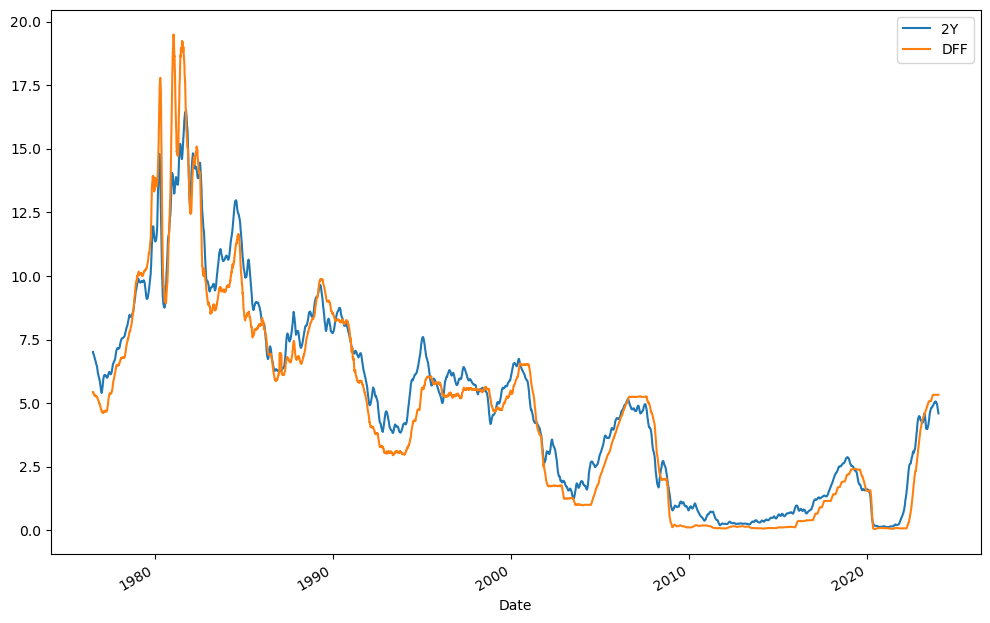

In [5]:
# check
df[['2Y', 'DFF']].dropna().fillna(method='bfill').rolling(30).mean().plot(figsize= (12,8))

In [6]:
# define momentum
# ======================================================================================================================
df_sm = make_sma(df[['Slope2Y']], spans=[50])
df_all = df.join(df_sm).dropna()

# generate signal
# ======================================================================================================================
df_all['Signal_ls'] = np.where(df_all['Slope2Y'] > df_all['Slope2Y_sm50'], 1, -1)
df_all['Signal_ln'] = np.where(df_all['Slope2Y'] > df_all['Slope2Y_sm50'], 1, 0)

<Axes: xlabel='Date'>

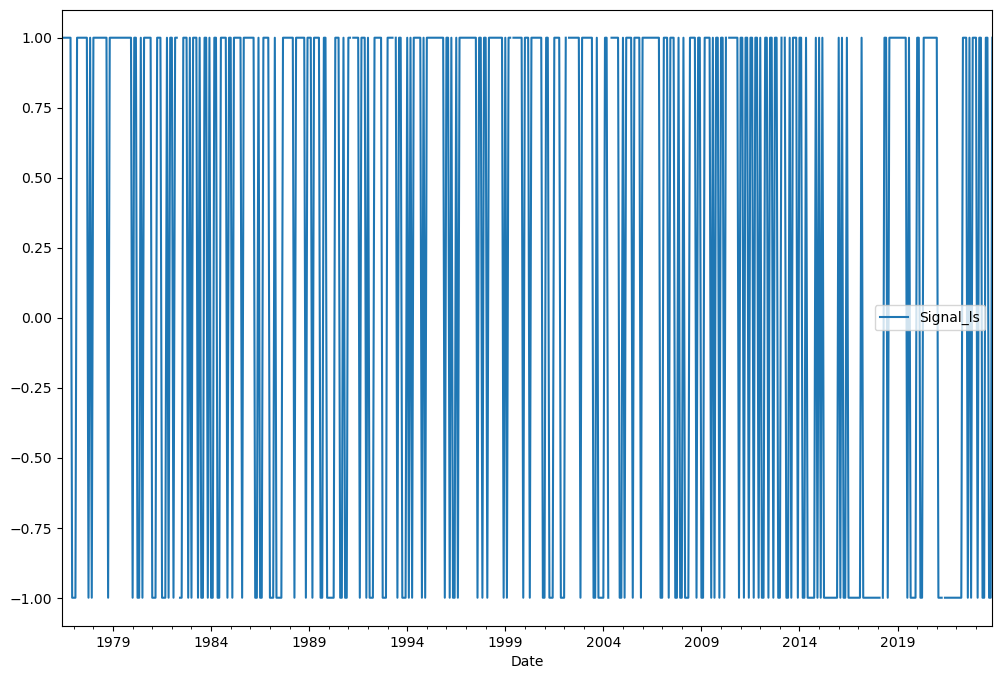

In [7]:
df_all[['Signal_ls']].dropna().asfreq('BM').plot(figsize=(12,8))

In [8]:
# Get data trading instruments: EURUSD, Stocks, Japan
# ======================================================================================================================
df_stock = get_stock_prices(yahoo_tickers=['^IXIC'], wide_format=True)
df_stock = df_stock.rename(columns={'^IXIC': 'Nasdaq'})
#df_fx = get_FX_spots(currencies=['EUR', 'JPY'], wide_format=True)
df_fx = get_fx(cross = "JPYUSD")

df_assets = pd.concat([df_stock, df_fx], axis=1)
df_assets.index.name = df_all.index.name

# merge all
# ======================================================================================================================
df_all = df_all.join(df_assets)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 8683.86it/s]


get_stock_prices took 1.293sec


/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/pypfopt/expected_returns.py:56: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Call ffill before calling pct_change to retain current behavior and silence this warning.
  returns = prices.pct_change().dropna(how="all")


<Axes: ylabel='Density'>

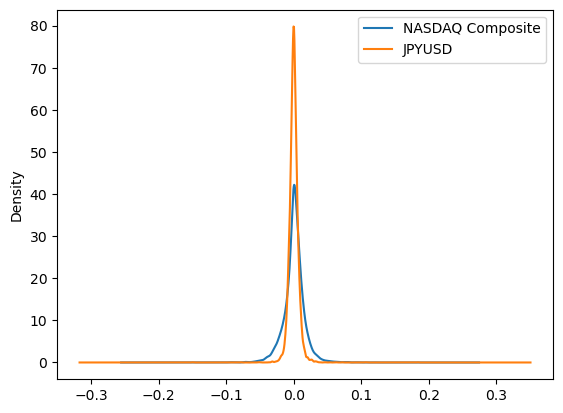

In [9]:
returns_from_prices(df_assets).dropna().plot.density()


/var/folders/7g/gr9fl0cx43g5f42xf78n_str0000gn/T/ipykernel_34444/3486337420.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Call ffill before calling pct_change to retain current behavior and silence this warning.
  performance(signal=df_all['Signal_ls'], returns=df_all['JPYUSD'].pct_change()).dropna().cumsum().plot()


<Axes: xlabel='Date'>

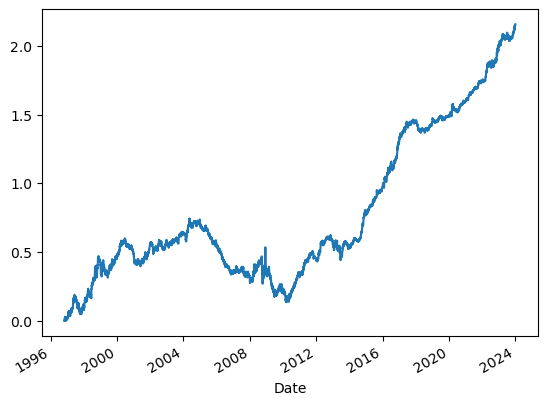

In [10]:
performance(signal=df_all['Signal_ls'], returns=df_all['JPYUSD'].pct_change()).dropna().cumsum().plot()

In [11]:
# performance
# ======================================================================================================================
df_perm = pd.DataFrame(index=df_all.index)
for col in ['JPYUSD']:
    # df_perm[col] = performance(signal=df_all['Signal'], returns=np.log(df_all[col]).diff()).cumsum()
    ret_temp = returns_from_prices(df_all[col])
    df_perm[col] = performance(signal=df_all['Signal_ls'], returns=ret_temp)
    #df_perm[col + '_no_TC'] = performance(signal=df_all['Signal_ls'], returns=ret_temp, bps=0)
    df_perm[col + '_ln'] = performance(signal=df_all['Signal_ln'], returns=ret_temp)
    # df_perm[col + 'str2'] = performance(signal=df_all['Signal2'], returns=np.log(df_all[col]).diff())

/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/pypfopt/expected_returns.py:56: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Call ffill before calling pct_change to retain current behavior and silence this warning.
  returns = prices.pct_change().dropna(how="all")


/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: Fut

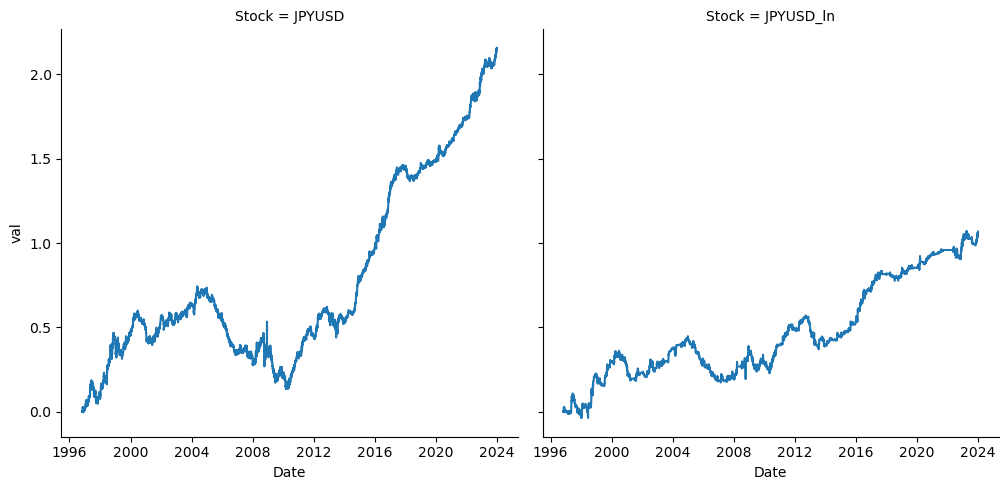

In [12]:
# from wide to long to plot
# ======================================================================================================================
dfm = df_perm.cumsum().dropna().reset_index().melt(id_vars='Date', var_name='Stock', value_name='val')
dfm['asset'] = [x.split('str')[0] for x in dfm.Stock]
g = sns.relplot(data=dfm, x='Date', y='val', col='Stock', col_wrap=3, kind='line')

In [13]:
# stats
df_perm_stats = performance_overview(df_perm, short=True).sort_values(by=['cagr'], ascending=False)
df_perm_stats

/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/ffn/core.py:1258: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return daily_prices[-1] / monthly_prices[-2] - 1
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/ffn/core.py:1270: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return daily_prices[-1] / yearly_prices[-2] - 1
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/ffn/core.py:232: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated 

,start,end,total_return,cagr,max_drawdown,yearly_sharpe,yearly_sortino,calmar
JPYUSD,1996-10-31 00:00:00,2023-12-28 00:00:00,6.117909,0.074945,-0.498288,0.59954,1.617636,0.150406
JPYUSD_ln,1996-10-31 00:00:00,2023-12-28 00:00:00,1.653342,0.036586,-0.243313,0.448323,1.038032,0.150367


In [14]:
ret_bench = df_stock.pct_change()
df_temp = df_perm.join(ret_bench).dropna()

In [40]:
qs.stats.monthly_returns(returns=df_perm[['JPYUSD']].dropna(), eoy=True)

/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/quantstats/stats.py:1013: UserWarning: Pandas DataFrame was passed (Series expected). Only first column will be used.
  warn(


,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,EOY
1996,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003339,0.024248,0.027669
1997,0.035601,-0.017896,0.012629,0.030879,0.064291,0.003785,-0.031110,-0.033598,-0.021246,0.007587,0.001035,0.020394,0.069830
1998,0.037037,0.005887,0.067762,-0.003440,-0.021352,0.088369,0.028206,0.031129,0.017610,0.039006,0.061508,-0.044770,0.343840
1999,-0.084849,0.079914,-0.034216,-0.020808,-0.006653,-0.002546,0.065186,-0.015738,0.015716,0.021022,0.035163,-0.008460,0.033440
2000,0.040251,0.017333,0.070221,-0.012071,-0.001657,0.015282,-0.044030,0.002759,-0.013502,-0.006067,-0.003496,-0.035444,0.024632
2001,-0.054872,-0.010548,0.023654,-0.013195,-0.034609,0.044322,-0.022698,0.045496,-0.004004,0.011038,0.028263,0.066054,0.074156
2002,0.003988,-0.036458,-0.005074,0.005311,-0.011985,0.037985,-0.002171,0.011399,-0.027908,-0.011378,0.012505,0.044993,0.018292
2003,-0.037619,0.010376,0.019160,-0.007403,-0.004024,0.025588,0.014048,-0.035856,0.047997,0.013852,0.016644,-0.003405,0.057523
2004,-0.015572,-0.042785,0.056204,0.067130,-0.005200,-0.011790,0.014088,0.020061,-0.008267,0.006076,-0.013029,0.001095,0.064758
2005,-0.036331,-0.013142,0.002765,0.025100,-0.034594,-0.015213,-0.010606,-0.032130,-0.024766,0.009108,-0.029702,-0.002295,-0.152108


In [38]:
qs.stats.monthly_returns(returns=df_temp[['NASDAQ Composite']], eoy=True)

/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/quantstats/stats.py:1013: UserWarning: Pandas DataFrame was passed (Series expected). Only first column will be used.
  warn(


,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,EOY
1996,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.012668,0.053882,-0.001222,0.065928
1997,0.056866,-0.051346,-0.066692,0.031972,0.110695,0.029815,0.105224,-0.004072,0.061972,-0.056301,0.008069,-0.018869,0.205082
1998,0.031210,0.093339,0.036809,0.017830,-0.047923,0.065137,-0.011796,-0.199285,0.129792,0.009535,0.102645,0.124722,0.350449
1999,0.142838,-0.086939,0.075773,0.033095,-0.028448,0.087269,-0.017732,0.038226,0.002486,0.069326,0.110100,0.219759,0.813406
2000,-0.031691,0.191947,-0.026372,-0.155739,-0.119086,0.166191,-0.050205,0.116634,-0.126839,-0.081060,-0.229016,-0.049043,-0.391904
2001,0.122326,-0.223931,-0.144793,0.149968,-0.002717,0.023715,-0.061748,-0.109366,-0.169838,0.127246,0.134988,0.010266,-0.215846
2002,-0.008393,-0.104724,0.065758,-0.085144,-0.042944,-0.094397,-0.092229,-0.010096,-0.108598,0.125190,0.145870,-0.096884,-0.300270
2003,-0.010932,0.012575,0.002729,0.091815,0.089872,0.016849,0.069152,0.043475,-0.012986,0.071106,0.020239,0.021992,0.494324
2004,0.031337,-0.017583,-0.017538,-0.037142,0.034680,0.030729,-0.078343,-0.026100,0.031957,0.036455,0.047924,0.037500,0.066935
2005,-0.051957,-0.005183,-0.025583,-0.038805,0.076273,-0.005444,0.062165,-0.014985,-0.000186,-0.009171,0.050300,-0.012316,0.016629


<Axes: >

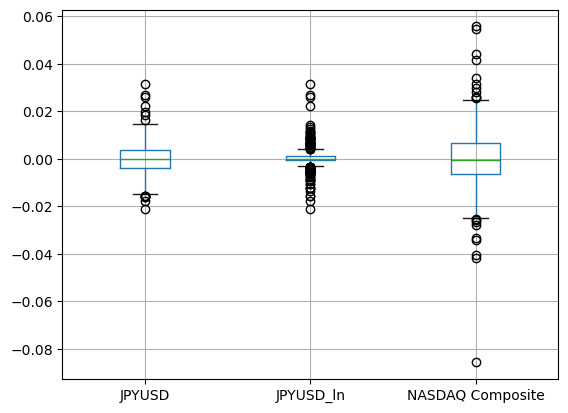

In [24]:
monthly = df_temp.resample('M').last()
monthly.boxplot()

In [25]:
get_main_stats(df_temp[df_temp.index>='2012-01-01'])

get_main_stats took 88.92ms


,total_ret,cagr,adjusted_sortino,sharpe,calmar,max_drawdown
JPYUSD,4.326718,0.149687,1.088094,1.006774,0.591745,-0.170843
JPYUSD_ln,0.745985,0.047572,0.007703,0.007199,0.176228,-0.185029
NASDAQ Composite,4.715961,0.156469,0.560835,0.570972,0.285726,-0.369499


In [26]:
ret_boostp = bootstrappingTS(df_perm['JPYUSD'].dropna(), n_samples=10000, bootstrap_type='mbb', block_size=365*2, 
                             optimal_block = False, 
                                          seed=123)

bootstrappingTS took 3.202sec


In [27]:
stats_boostp = get_main_stats(ret_boostp)
stats_boostp[['cagr']].plot.density()

get_main_stats took 77.858sec


In [28]:
df_hist = get_main_stats(df_temp)
df_hist

get_main_stats took 93.89ms


,total_ret,cagr,adjusted_sortino,sharpe,calmar,max_drawdown
JPYUSD,5.959290,0.074001,0.225192,0.223450,0.101318,-0.498667
JPYUSD_ln,1.586166,0.035583,-0.114071,-0.107213,0.100421,-0.243313
NASDAQ Composite,9.057051,0.088652,0.237522,0.239367,0.077387,-0.780454


In [29]:
boost_mean = ret_boostp.resample('Y').last().mean().mean()

In [30]:
hist_ret = returns_from_prices(df_assets['JPYUSD']).resample('Y').last().dropna()

/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/pypfopt/expected_returns.py:56: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Call ffill before calling pct_change to retain current behavior and silence this warning.
  returns = prices.pct_change().dropna(how="all")


/var/folders/7g/gr9fl0cx43g5f42xf78n_str0000gn/T/ipykernel_34444/3728325179.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(ret_boostp.resample('Y').last().mean(), hist=True)
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be re

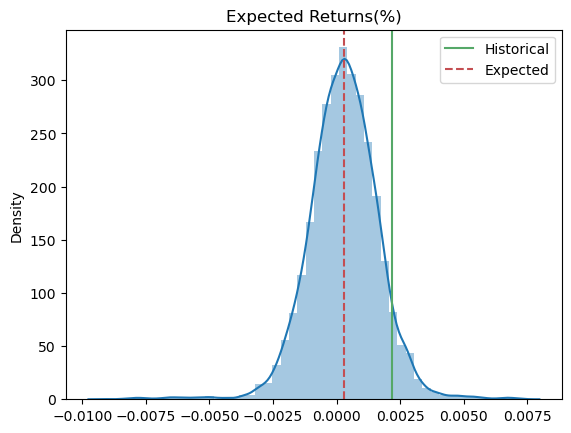

In [31]:
sns.distplot(ret_boostp.resample('Y').last().mean(), hist=True)
plt.axvline(x=hist_ret.mean(), color='g', linestyle='-', label='Historical')
plt.axvline(x=boost_mean, color='r', linestyle='--', label='Expected')
plt.title('Expected Returns(%)')
plt.legend()

/var/folders/7g/gr9fl0cx43g5f42xf78n_str0000gn/T/ipykernel_34444/731771019.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  boost_sharp = stats_boostp[['sharpe']].mean()[0]
/var/folders/7g/gr9fl0cx43g5f42xf78n_str0000gn/T/ipykernel_34444/731771019.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(stats_boostp[metric], hist=True)
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: 

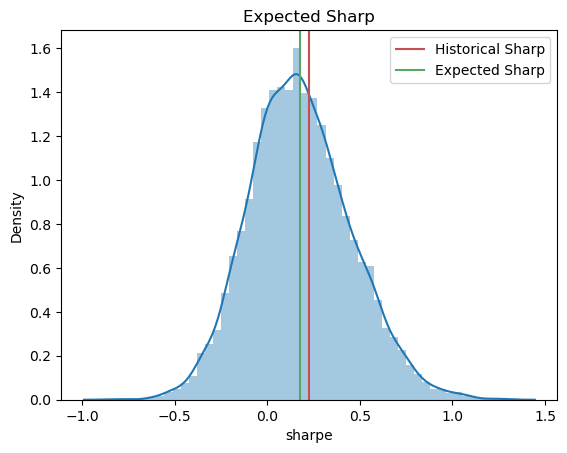

In [32]:
metric = 'sharpe'
hist_sharp = df_hist.loc['JPYUSD']['sharpe']
boost_sharp = stats_boostp[['sharpe']].mean()[0]
sns.distplot(stats_boostp[metric], hist=True)
plt.axvline(x=hist_sharp, color='r', linestyle='-', label = 'Historical Sharp')
plt.axvline(x=boost_sharp, color='g', linestyle='-', label = 'Expected Sharp')
plt.title('Expected Sharp')
plt.legend()

/var/folders/7g/gr9fl0cx43g5f42xf78n_str0000gn/T/ipykernel_34444/1974710096.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(hist_ret*100, hist=True)
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version.

<Axes: xlabel='JPYUSD', ylabel='Density'>

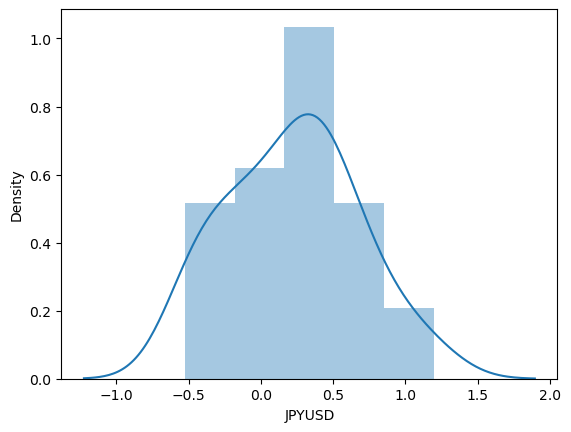

In [33]:
hist_ret.index = pd.to_datetime(hist_ret.index).normalize()
sns.distplot(hist_ret*100, hist=True)

/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/numpy/core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.prod with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/numpy/core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.prod with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/numpy/core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.prod with axis=None is deprecated, in a future version this will reduce over both axes and r

                           Benchmark    Strategy
-------------------------  -----------  -----------
Start Period               1996-11-01   1996-11-01
End Period                 2023-12-28   2023-12-28
Risk-Free Rate             5.0%         5.0%
Time in Market             100.0%       100.0%

Cumulative Return          893.12%      595.93%
CAGR﹪                     6.01%        5.05%

Sharpe                     0.27         0.25
Prob. Sharpe Ratio         4.51%        25.57%
Smart Sharpe               0.24         0.22
Sortino                    0.38         0.36
Smart Sortino              0.33         0.32
Sortino/√2                 0.27         0.26
Smart Sortino/√2           0.24         0.23
Omega                      1.05         1.05

Max Drawdown               -78.05%      -49.87%
Longest DD Days            6179         4005
Volatility (ann.)          24.97%       11.96%
R^2                        0.0          0.0
Information Ratio          -0.01        -0.01
Calmar           

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2004-05-14,2010-05-04,2015-05-01,4005,-49.866741,-48.696698
2,2000-06-23,2001-06-04,2003-11-26,1252,-18.780746,-17.927388
3,1998-11-16,1999-06-11,2000-01-05,416,-14.922106,-13.824718
4,1997-06-12,1997-11-10,1998-03-27,289,-13.333828,-13.035688
5,2017-11-07,2018-04-18,2019-01-02,422,-9.213991,-8.934896


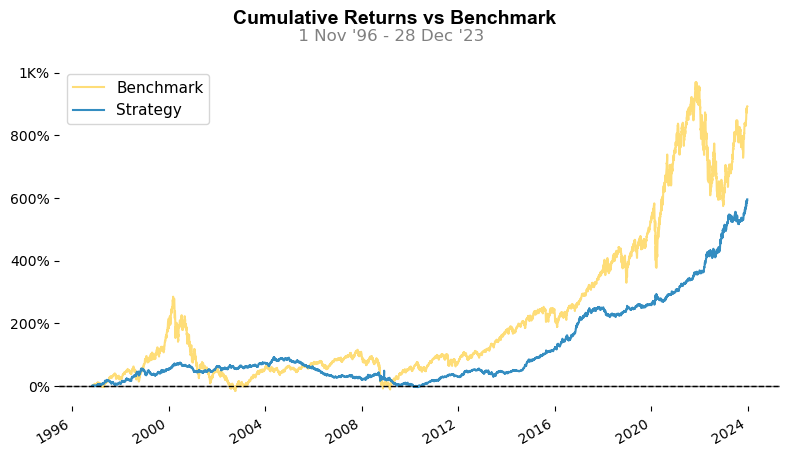

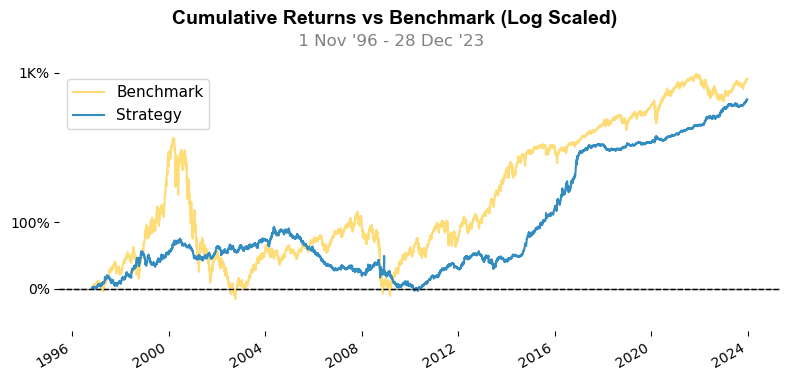

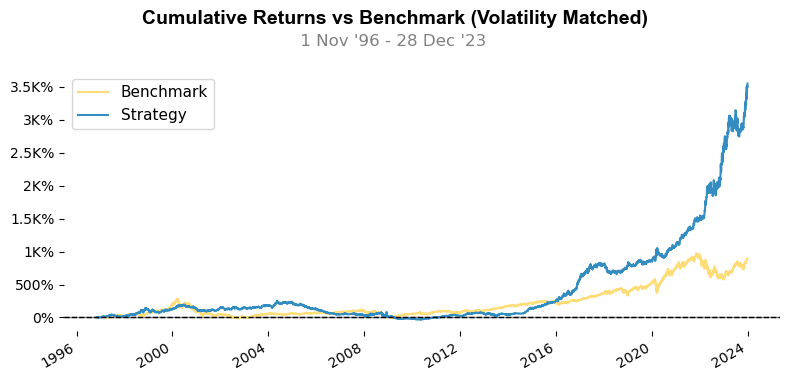

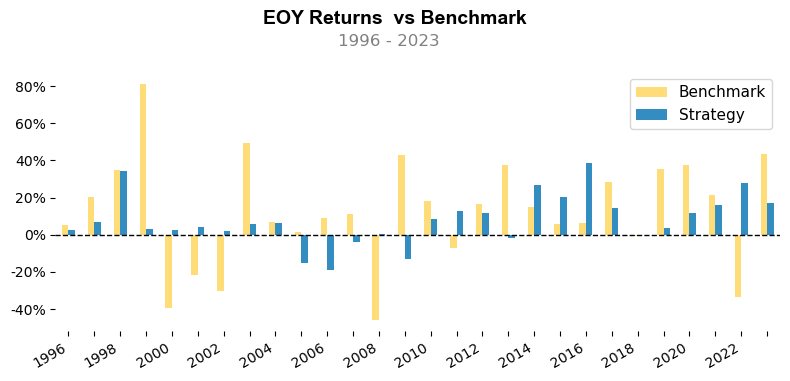

/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: Fut

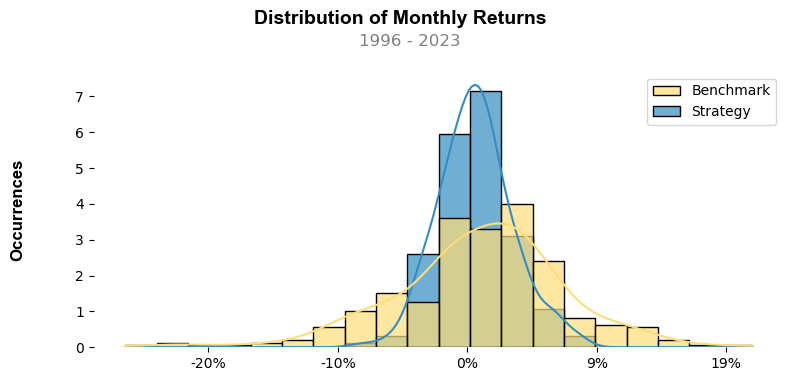

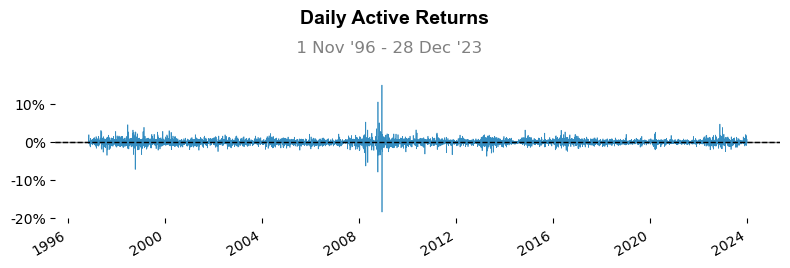

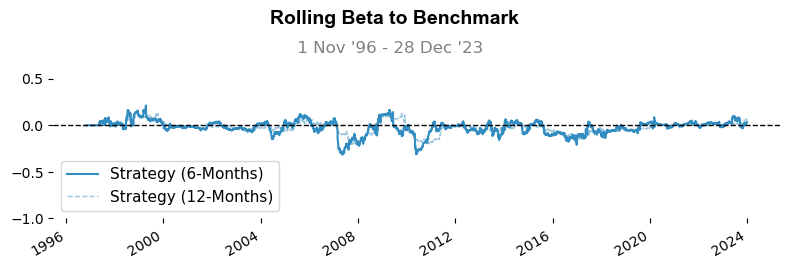

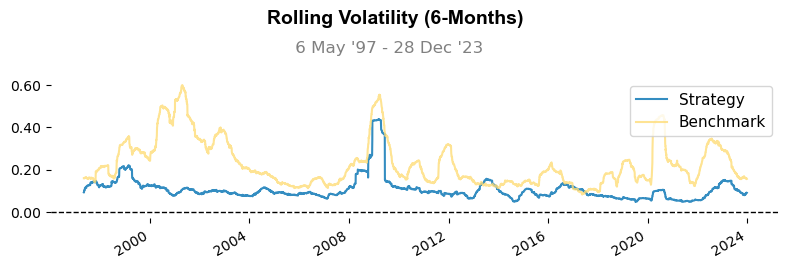

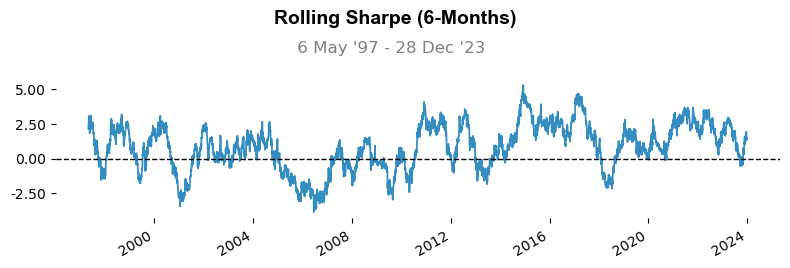

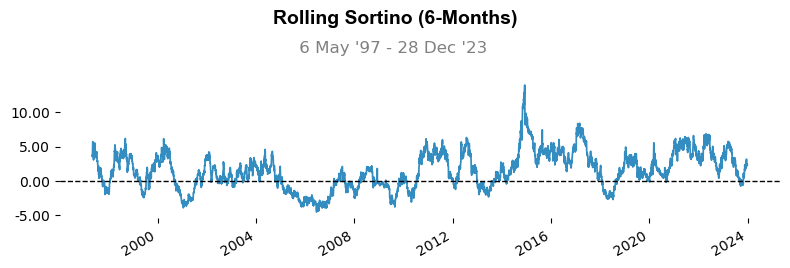

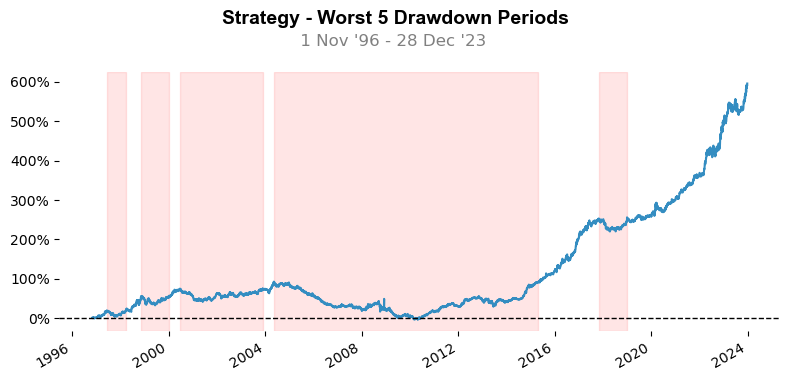

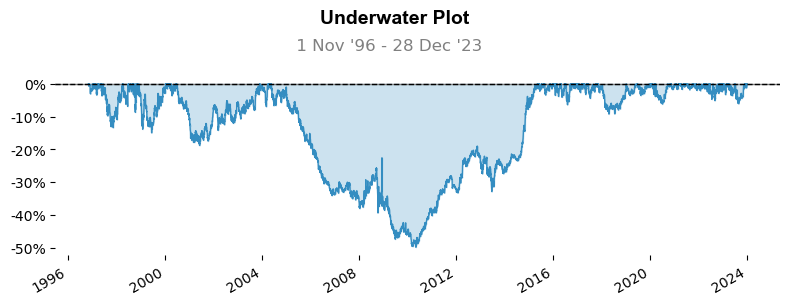

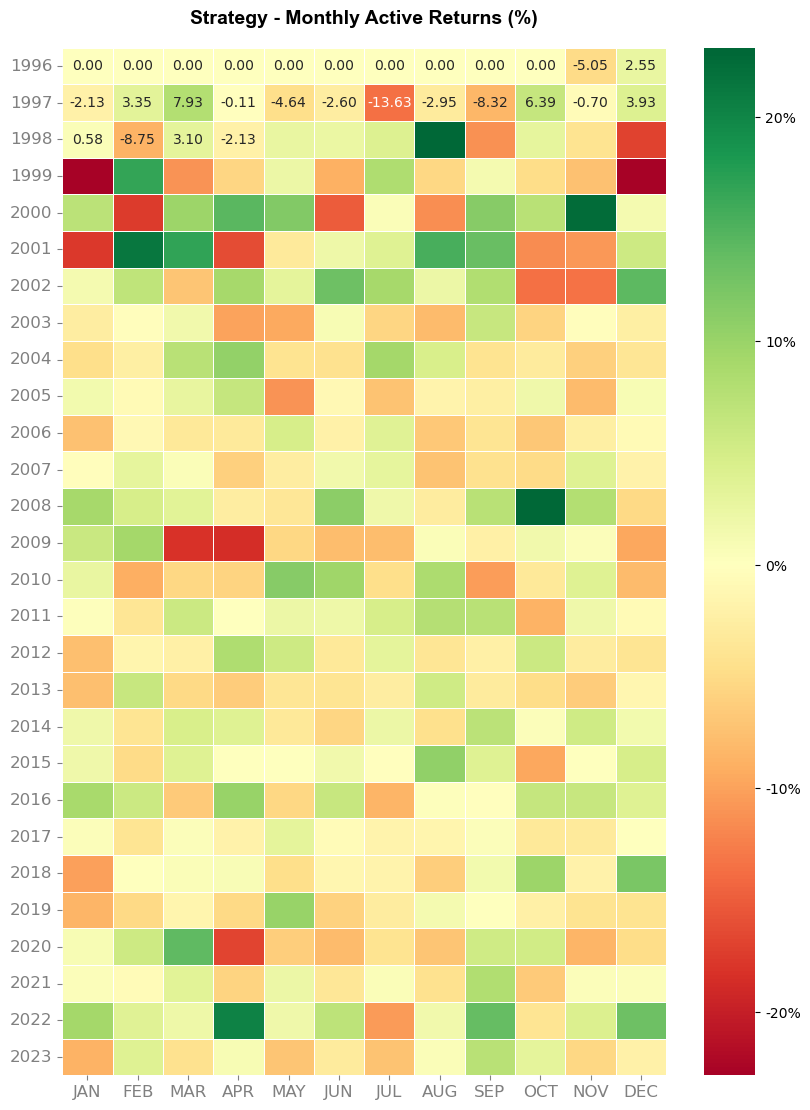

/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: Fut

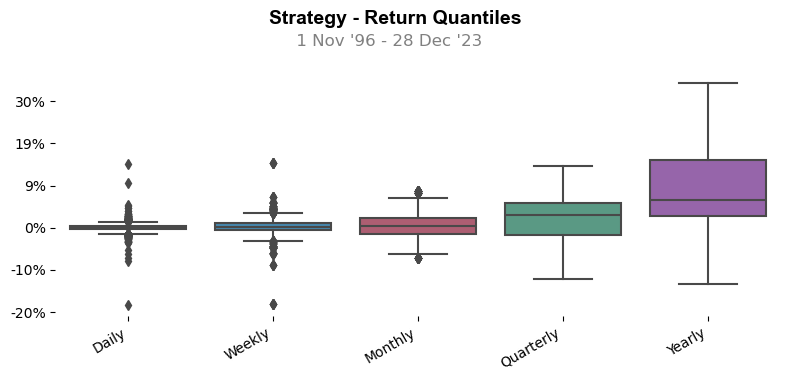

In [36]:
 qs.reports.full(df_temp['JPYUSD'], benchmark=df_temp['NASDAQ Composite'], rf=0.05)

/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/numpy/core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.prod with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/numpy/core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.prod with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/numpy/core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.prod with axis=None is deprecated, in a future version this will reduce over both axes and r

                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               1996-11-01   1996-11-01
End Period                 2023-12-28   2023-12-28
Risk-Free Rate             5.0%         5.0%
Time in Market             100.0%       59.0%

Cumulative Return          893.12%      158.62%
CAGR﹪                     6.01%        2.44%

Sharpe                     0.27         -0.12
Prob. Sharpe Ratio         4.51%        4.35%
Smart Sharpe               0.25         -0.11
Sortino                    0.38         -0.18
Smart Sortino              0.35         -0.17
Sortino/√2                 0.27         -0.13
Smart Sortino/√2           0.25         -0.12
Omega                      0.97         0.97

Max Drawdown               -78.05%      -24.33%
Longest DD Days            6179         2388
Volatility (ann.)          24.97%       8.26%
R^2                        0.01         0.01
Information Ratio          -0.02        -0.02
Calmar        

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2004-12-28,2007-02-22,2011-07-12,2388,-24.331258,-23.589100
2,2012-09-17,2013-07-19,2016-02-08,1240,-18.502911,-17.212506
3,2000-06-23,2002-04-15,2004-08-16,1516,-17.463909,-16.937019
4,1997-06-12,1998-01-06,1998-09-03,449,-13.892188,-12.661495
5,2023-03-28,2023-10-27,2023-12-27,275,-7.606856,-7.423379


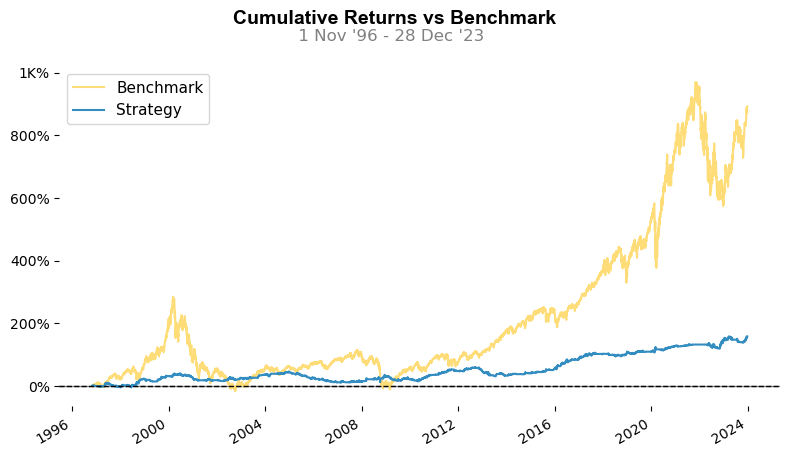

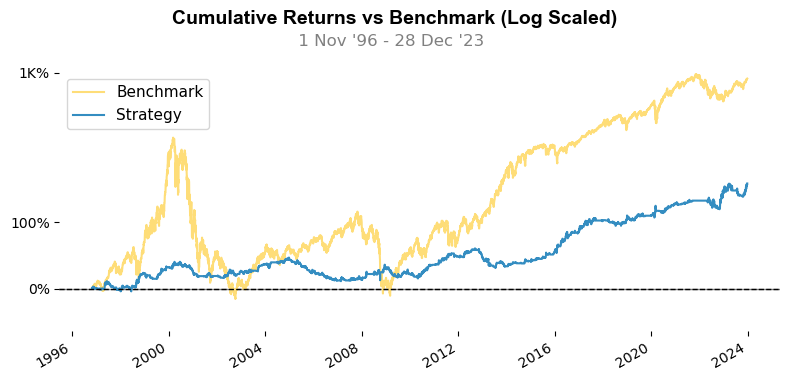

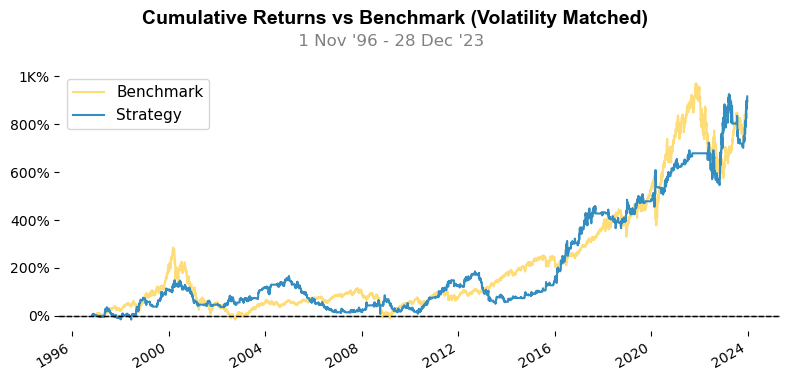

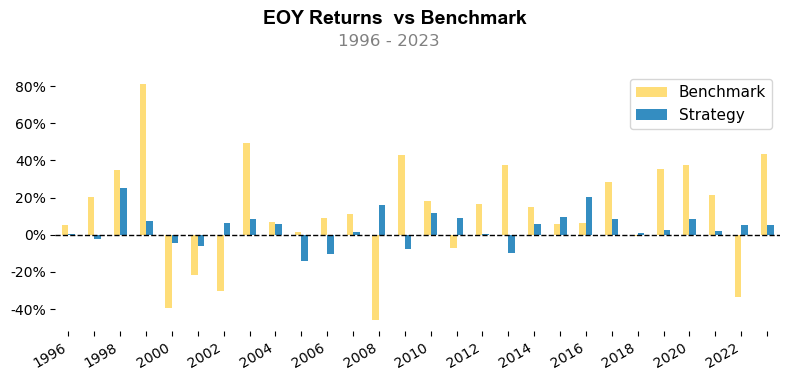

/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: Fut

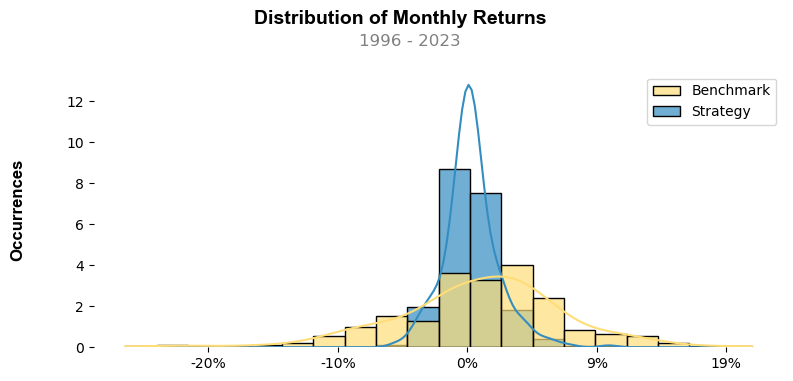

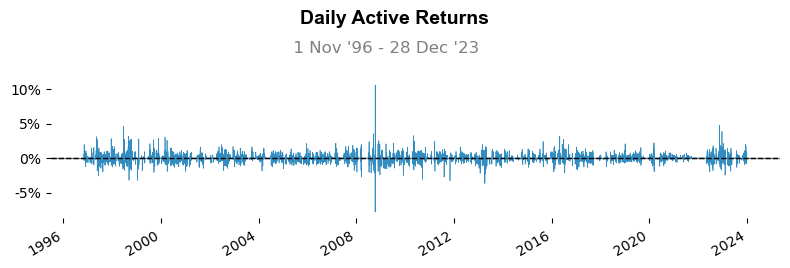

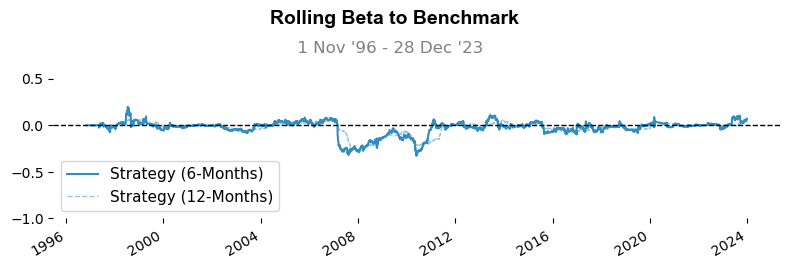

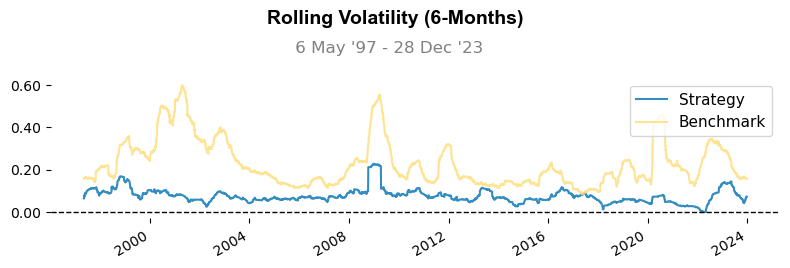

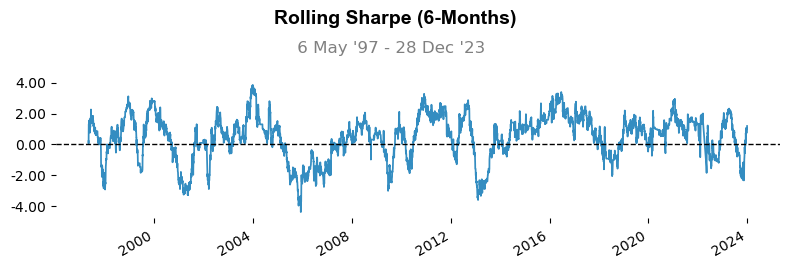

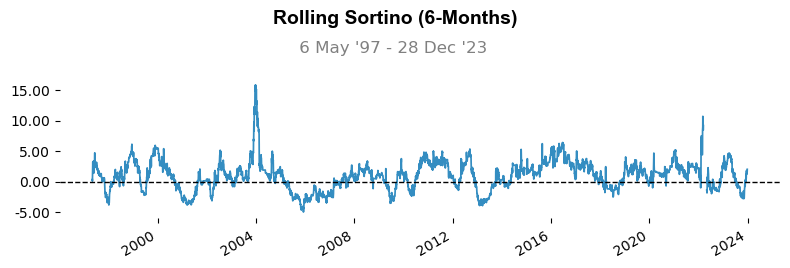

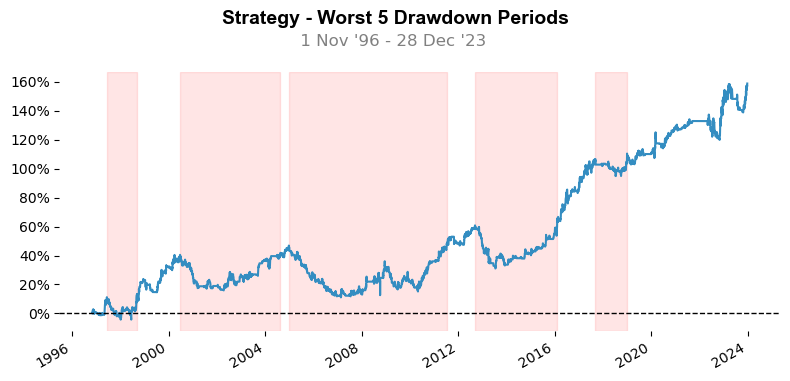

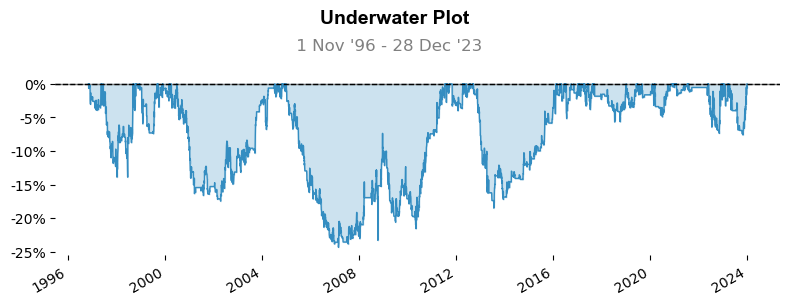

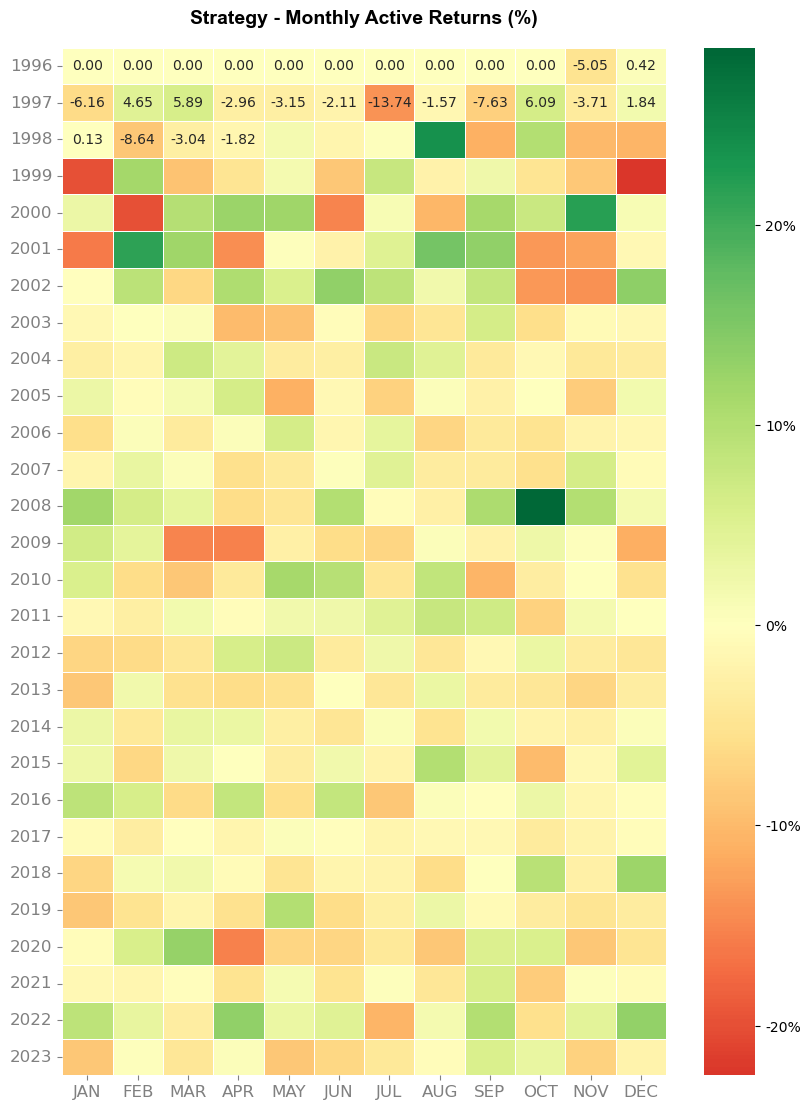

/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/safishajjouz/opt/anaconda3/envs/openBB_terminal/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: Fut

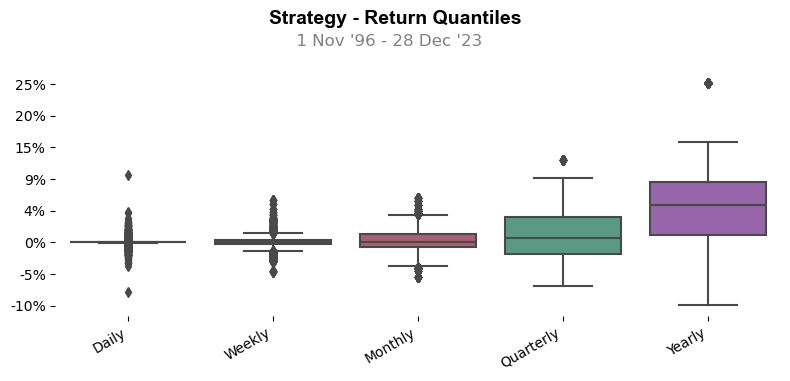

In [37]:
qs.reports.full(df_temp['JPYUSD_ln'], benchmark=df_temp['NASDAQ Composite'], rf=0.05)

In [ ]:
dist = prep_dist(ret_boostp)

In [ ]:
dist['0.95'].plot()

In [ ]:
dist_cum = ep.cum_returns(dist, starting_value=1)

In [ ]:
pd.set_option('display.float_format', str)
round(dist_cum['0.95'],2)

In [ ]:
plot_fan_chart(df_temp[['JPYUSD']],dist_cum, out_of_sample_date='2023-05-12',
                   starting_value=1,
                   chart_title='Expected Returns')

In [ ]:
from fanchart import load_boe_history, load_boe_parameters
from fanchart import fan

history = load_boe_history()
parameters = load_boe_parameters()
    


In [ ]:
history

In [ ]:
probs = [0.05, 0.20, 0.35, 0.65,0.80,  0.95]
parameters

In [ ]:
fan(pars=parameters, probs=probs, historic=history[history.Date >= '2018'])

In [ ]:
param = pd.concat([ret_boostp.median(axis=1), ret_boostp.std(axis=1), ret_boostp.skew(axis=1)], axis=1)
param.columns = ['Mode','Uncertainty', 'Skewness']
param = param.reset_index()
param

In [ ]:
hist = df_temp[['JPYUSD']].reset_index()
hist = hist.rename(columns={'JPYUSD':'Inflation'})
fan(pars=param, probs=probs, historic=hist[hist.Date >= '2020'])